# Import necessary libraries

In [1]:
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from scipy.stats import chi2_contingency, f_oneway, iqr
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    jaccard_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    make_scorer,
    average_precision_score
)
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold, RepeatedStratifiedKFold
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from jaqpotpy import Jaqpot
from jaqpotpy.datasets import JaqpotTabularDataset
from jaqpotpy.models.sklearn import SklearnModel
from jaqpotpy.doa import Leverage, BoundingBox

# General Settings

In [3]:
DATASET = 'ecotoxicity_data'

RANDOM_STATE = 42
NUM_SPLITS = 5

# Load Ecotoxicity Dataset and Create DataFrame

In [5]:
# Load Dataset
model = DATASET
df = pd.read_csv(f'{model}.csv')

In [7]:
# Check shape and features of the Dataset
features = df.columns.to_list()
print(f"Original dataset: {df.shape}")
print(f"\nFeature names: \n{features}")

Original dataset: (99, 79)

Feature names: 
['Study_id', 'Instance', 'Monomer_A', 'Monomer_B', 'Monomer_C', '3HB_ratio', '3HV_ratio', '4HV_ratio', 'Mw', 'Units_Mw', 'Mn', 'Units_Mn', 'PDI', 'Shape', 'Diameter', 'Diameter_Units', 'Length', 'Units_Length', 'Thickness', 'Units_Thickness', 'Zeta_Potential', 'Units_Zeta_Potential', 'Additive1', 'Additive1_Name', 'Additive1_Percentage', 'Additive1_Use', 'Additive2_Name', 'Additive2_Percentage', 'Additive2_Use', 'Additive3_Name', 'Additive3_Percentage', 'Additive3_Use', 'Polymer_Percentage', 'Species_Name', 'Species_Group', 'Initial_Organism_Age', 'Units_Initial_Organism_Age', 'Initial_Organism_Size', 'Units_Initial_Organism_Size', 'Exposure_type', 'Media_type', 'Test_location', 'Tested_Concentration', 'Units_Tested_Concentration', 'Observation_Period', 'Units_Observation_Period', 'Exposure_Regime', 'EC_10', 'EC_10_Units', 'EC_20', 'EC_20_Units', 'EC_50', 'EC_50_Units', 'Toxic_Units', 'LC_50', 'LC_50_Units', 'LD_50', 'LD_50_Units', 'Mortality

In [9]:
# Remove identifiers, units measurements, features with a single value or few examples per category
cols_identifiers_units = ['Study_id', 'Instance', 'Monomer_A', 'Monomer_B', 'Monomer_C', 'Units_Mw', 'Units_Mn', 'Diameter_Units',
                          'Units_Length', 'Units_Length', 'Units_Thickness', 'Units_Zeta_Potential', 'Additive1', 'Additive1_Name',
                          'Additive2_Name', 'Additive3_Name', 'Units_Initial_Organism_Age', 'Initial_Organism_Age', 'Units_Tested_Concentration',
                          'Units_Observation_Period', 'EC_10_Units', 'EC_50_Units', 'Toxic_Units', 'LC_50_Units', 'LD_50_Units', 'Size_Increase_Units', 
                          'SGR_Units', 'WG_Units', 'Plant_Height_Units', 'Shoot_Biomass_Units', 'Test_location', '4HV_ratio'
                          ] 
df = df.drop(columns=cols_identifiers_units)   
print(f"After column removal: {df.shape}")

After column removal: (99, 48)


In [11]:
# Remove ecotoxicity output related columns
cols_leaky = ['EC_10', 'EC_50', 'LC_50', 'LD_50', 'Mortality_Percentage', 
              'Body_Mass_Change_Percentage', 'Size_Increase', 'Number_of_Juveniles', 
              'Number_of_Cocoons', 'SGI_Percentage', 'Survival_rate_percentage', 
              'Normal_Plutei_Percentage', 'SGR', 'WG', 'Plant_Height', 'Shoot_Biomass',
              'Foliar_C_N_ratio', 'Plant_Growth', 'Toxicity_Grade'
             ] 
df = df.drop(columns=cols_leaky)   
print(f"After cytotoxicity related columns removal: {df.shape}")

After cytotoxicity related columns removal: (99, 29)


In [13]:
# Remove redundant features
cols_redundant = ['Species_Name', # it has been with Species Group
                  'Polymer_Percentage', # it is related to HB and HV ratios
                  '3HB_ratio', # it is related to HV ratio
              #    'Toxicity'# it is expressed by 'Observation period' 
                 ] 
df = df.drop(columns=cols_redundant)   
print(f"After cytotoxicity related columns removal: {df.shape}")

After cytotoxicity related columns removal: (99, 26)


In [15]:
# Change feature 3HV ratio name for Jaqpot compatibility
df.rename(columns={'3HV_ratio': 'hv_ratio'}, inplace=True)

# Train/Test Split

In [17]:
# Set the target feature
target = 'Toxicity_Classification'

# Split features by their type
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in df.columns
                    if c not in numerical_cols and c != target]

print(f"Numerical features ({len(numerical_cols)}):")
for c in numerical_cols: print(f"  - {c}")
print(f"\nCategorical features ({len(categorical_cols)}):")
for c in categorical_cols: print(f"  - {c}")

Numerical features (15):
  - hv_ratio
  - Mw
  - Mn
  - PDI
  - Diameter
  - Length
  - Thickness
  - Zeta_Potential
  - Additive1_Percentage
  - Additive2_Percentage
  - Additive3_Percentage
  - Initial_Organism_Size
  - Tested_Concentration
  - Observation_Period
  - EC_20

Categorical features (10):
  - Shape
  - Additive1_Use
  - Additive2_Use
  - Additive3_Use
  - Species_Group
  - Units_Initial_Organism_Size
  - Exposure_type
  - Media_type
  - Exposure_Regime
  - EC_20_Units


In [19]:
# Drop rows with null values at the target features to be able to make stratified split
df = df[df[target].notna()]

In [21]:
X = df[numerical_cols + categorical_cols].copy()
y = df[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print('Train size', X_train.shape, 'class proportions', pd.Series(y_train).value_counts()) 
print('\nTest size', X_test.shape, 'class proportions', pd.Series(y_test).value_counts())

Train size (79, 25) class proportions Toxicity_Classification
Non_Toxic           53
Moderately_Toxic    17
Toxic                9
Name: count, dtype: int64

Test size (20, 25) class proportions Toxicity_Classification
Non_Toxic           14
Moderately_Toxic     4
Toxic                2
Name: count, dtype: int64


In [23]:
# Check high missing values on the training set 
# Missing values overview for all columns in the dataset
missing_df = pd.DataFrame({
    'Missing Values':   X_train.isnull().sum(),
    'Missing Percentage (%)': (X_train.isnull().sum() / len(X_train) * 100).round(1)
}).sort_values('Missing Percentage (%)', ascending=False)

# missing_df.to_excel('missing_values.xlsx', index=True)

print(f"Total rows: {len(X_train)}\n")
missing_df

Total rows: 79



,Missing Values,Missing Percentage (%)
EC_20_Units,74,93.7
Initial_Organism_Size,74,93.7
Units_Initial_Organism_Size,74,93.7
EC_20,74,93.7
Length,72,91.1
Zeta_Potential,72,91.1
Thickness,61,77.2
Mn,50,63.3
PDI,50,63.3
Mw,50,63.3


In [25]:
# Find columns with high number of missing values in the training set only
miss_thresh = 0.16  # 20% of the values are missing
high_missing_cols_train = [
    c for c in X_train.columns
    if X_train[c].isnull().sum() / len(X_train) > miss_thresh
    # and c != 'Tested_Concentration' # exclude concentration because it plays an important role in cytotoxicity
]

# Apply same column drop to train and test set
X_train = X_train.drop(columns=high_missing_cols_train)
X_test  = X_test.drop(columns=high_missing_cols_train)

# Drop null rows from train and test set
mask_train = X_train.notna().all(axis=1)
X_train = X_train[mask_train]
y_train = y_train[mask_train]

mask_test = X_test.notna().all(axis=1)
X_test = X_test[mask_test]
y_test = y_test[mask_test]

# Check the new train and test sets
print('Train size', X_train.shape, 'class proportions', pd.Series(y_train).value_counts()) 
print('\nTest size', X_test.shape, 'class proportions', pd.Series(y_test).value_counts())

Train size (59, 12) class proportions Toxicity_Classification
Non_Toxic           38
Moderately_Toxic    13
Toxic                8
Name: count, dtype: int64

Test size (14, 12) class proportions Toxicity_Classification
Non_Toxic           9
Moderately_Toxic    4
Toxic               1
Name: count, dtype: int64


In [27]:
# Merging Toxic and Moderately_Toxic to Toxic due to very few samples of Toxic for classifier to learn
y_train = y_train.replace({
    'Toxic': 'Toxic',
    'Moderately_Toxic': 'Toxic',
    'Non_Toxic': 'Non_Toxic'
})

y_test = y_test.replace({
    'Toxic': 'Toxic',
    'Moderately_Toxic': 'Toxic',
    'Non_Toxic': 'Non_Toxic'
})

print('Train size', X_train.shape, 'class proportions', pd.Series(y_train).value_counts()) 
print('\nTest size', X_test.shape, 'class proportions', pd.Series(y_test).value_counts())

Train size (59, 12) class proportions Toxicity_Classification
Non_Toxic    38
Toxic        21
Name: count, dtype: int64

Test size (14, 12) class proportions Toxicity_Classification
Non_Toxic    9
Toxic        5
Name: count, dtype: int64


# Exploratory Data Analysis (fit on train set, apply on train and test set)

## Examine Numerical Features

In [29]:
for column in X_train.select_dtypes(include=[np.number]).columns.tolist():
    print("\n")
    print(X_train[column].describe())



count    59.000000
mean      1.364407
std       3.417539
min       0.000000
25%       0.000000
50%       0.000000
75%       0.000000
max      12.000000
Name: hv_ratio, dtype: float64


count    59.000000
mean     11.042373
std      21.188255
min       0.000000
25%       0.000000
50%       0.000000
75%       0.000000
max      72.000000
Name: Additive1_Percentage, dtype: float64


count    59.000000
mean      0.525424
std       2.011655
min       0.000000
25%       0.000000
50%       0.000000
75%       0.000000
max      10.000000
Name: Additive2_Percentage, dtype: float64


count    59.000000
mean      0.203390
std       0.609682
min       0.000000
25%       0.000000
50%       0.000000
75%       0.000000
max       2.000000
Name: Additive3_Percentage, dtype: float64


count     59.000000
mean      27.020127
std       46.350404
min        0.020833
25%        3.000000
50%        7.000000
75%       28.000000
max      183.000000
Name: Observation_Period, dtype: float64


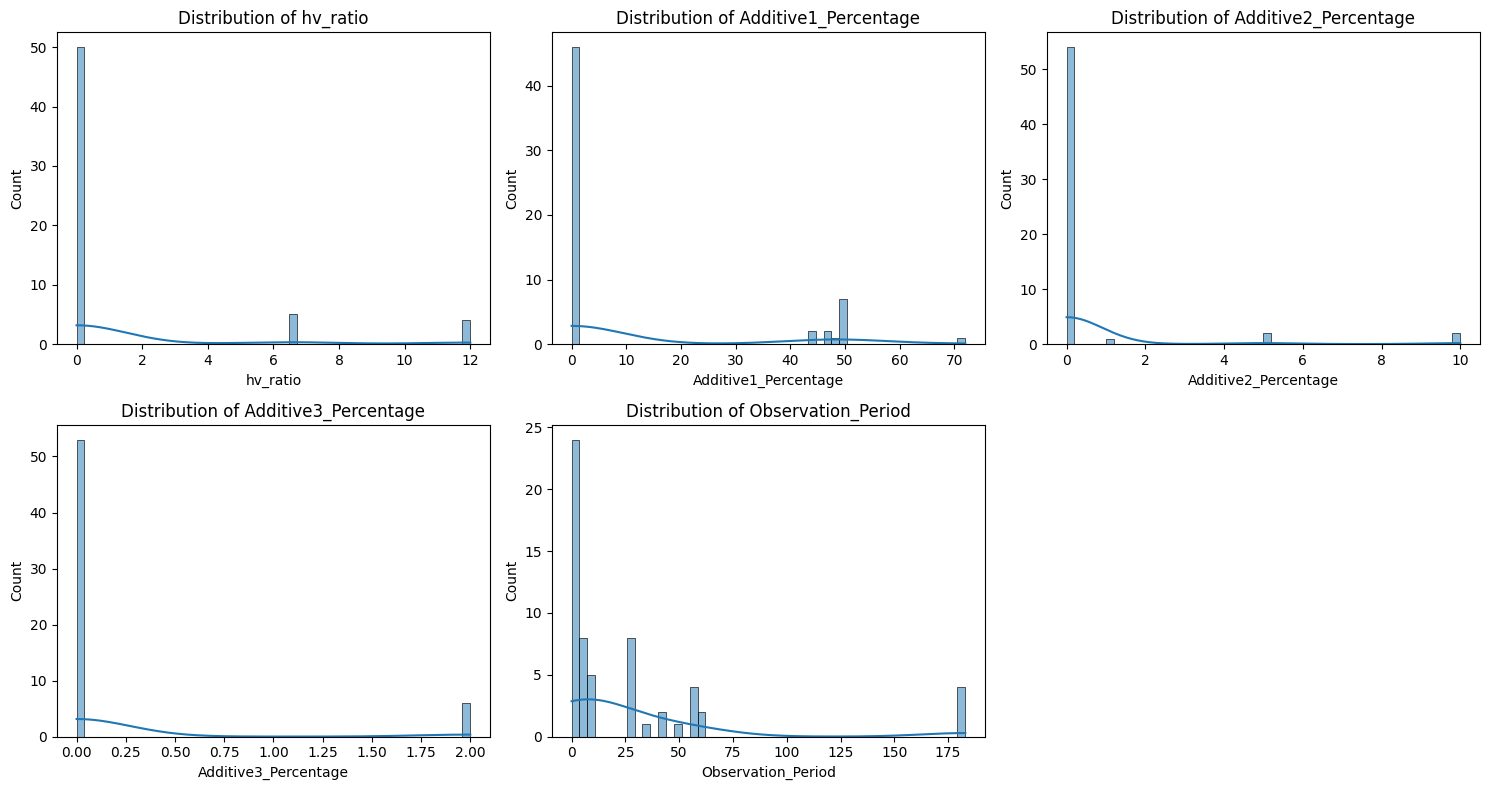

In [31]:
# Plot the distribution of numerical features
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)
plt.figure(figsize=(n_cols * 5, n_rows * 4))
for i, col in enumerate(num_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(X_train[col], kde=True, bins=50)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

## Outlier Detection

In [33]:
apply_outlier_detection = False  # Set to False to skip

if apply_outlier_detection:
    data = X_train.select_dtypes(include=[np.number])
    outlier_mask = pd.DataFrame(False, index=X_train.index, columns=data.columns)

    for col in data.columns:
        Q1 = np.percentile(data[col], 25)
        Q3 = np.percentile(data[col], 75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outlier_mask[col] = (data[col] < lower) | (data[col] > upper)

    outlier_rows = outlier_mask.any(axis=1)
    X_train_clean = X_train[~outlier_rows]
    y_train_clean = y_train[~outlier_rows]

    print(f"Removed {outlier_rows.sum()} outlier rows. Remaining: {len(X_train_clean)}")
else:
    X_train_clean = X_train.copy()
    y_train_clean = y_train.copy()
    print("Outlier detection skipped.")

Outlier detection skipped.


## Examine Categorical Features

In [36]:
for column in X_train_clean.select_dtypes(include=['object']).columns.tolist():
    print("\n")
    print(X_train[column].value_counts())

C:\Users\leoni\AppData\Local\Temp\ipykernel_26456\1195282443.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for column in X_train_clean.select_dtypes(include=['object']).columns.tolist():




Additive1_Use
not_applicable    46
Plasticizer        6
Structural         3
Flexibilizer       3
Polymer_Matrix     1
Name: count, dtype: int64


Additive2_Use
not_applicable         53
Natural_Antioxidant     6
Name: count, dtype: int64


Additive3_Use
not_applicable    53
Chain_Extender     6
Name: count, dtype: int64


Species_Group
Aquatic_Organisms    35
Terrestrial_Plant    24
Name: count, dtype: int64


Exposure_type
Waterborne       29
Soil             23
Orally            4
Dietary           2
Mulch_extract     1
Name: count, dtype: int64


Media_type
Sandy_Soil                                9
Filtered_Seawater                         7
Standard_soil_with_5_compost              5
Artificial_Freshwater                     5
Egg_water                                 4
Agricultural_soil                         4
Diluted_biodegraded_synthetic_seawater    4
Standard_soil_with_10_compost             3
Artificial_Seawater                       3
Diluted_biodegraded_natural_seawat

## Handle Categorical Features

In [39]:
# Group Media type in smaller meaningfull categories
media_merge_map = {
    # Freshwater
    'Artificial_Freshwater': 'Freshwater',
    'Freshwater_simulation': 'Freshwater',
    'Freshwater':            'Freshwater',

    # Seawater
    'Filtered_Seawater':                       'Seawater',
    'Disinfected_Seawater':                    'Seawater',
    'Artificial_Seawater':                     'Seawater',
    'Autoclaved_Seawater':                     'Seawater',
    'Diluted_biodegraded_natural_seawater':    'Seawater',
    'Diluted_biodegraded_synthetic_seawater':  'Seawater',

    # Soil
    'Sandy_Soil':                    'Soil',
    'Agricultural_soil':             'Soil',
    'Standard_soil_with_5_compost':  'Soil',
    'Standard_soil_with_10_compost': 'Soil',
    'Potting_Substrate':             'Soil',

    # Other
    'Egg_water':        'Other',
    'Steinberg_medium': 'Other',
    'MS_plant_culture_medium_ME': 'Other',
}

X_train_clean['Media_type'] = X_train_clean['Media_type'].map(media_merge_map)
X_test['Media_type'] = X_test['Media_type'].map(media_merge_map)
print(X_train_clean['Media_type'].value_counts(normalize=True))
print(X_test['Media_type'].value_counts(normalize=True))

Media_type
Soil          0.389831
Seawater      0.355932
Other         0.135593
Freshwater    0.118644
Name: proportion, dtype: float64
Media_type
Soil          0.357143
Seawater      0.357143
Freshwater    0.142857
Other         0.142857
Name: proportion, dtype: float64


In [41]:
def fit_rare_category_collapser(X, cat_cols, min_freq=0.05, other_label='other'):
    """
    Learns which categories are rare from training data only.

    Parameters
    ----------
    X : pd.DataFrame
    cat_cols : list
    min_freq : float
        Minimum proportion to keep a category.
    other_label : str

    Returns
    -------
    rare_map : dict mapping column -> set of rare categories
    """
    rare_map = {}
    for col in cat_cols:
        freq = X[col].value_counts(normalize=True)
        rare_map[col] = set(freq[freq < min_freq].index)
    return rare_map


def transform_rare_categories(X, rare_map, other_label='other'):
    """
    Applies rare category collapsing learned from training data.

    Parameters
    ----------
    X : pd.DataFrame
    rare_map : dict from fit_rare_category_collapser
    other_label : str

    Returns
    -------
    X_transformed : pd.DataFrame
    """
    X = X.copy()
    for col, rare_cats in rare_map.items():
        X[col] = X[col].replace(rare_cats, other_label)
    return X


def fit_merge_small_other(X, cat_cols, min_count=5, other_label='other'):
    """
    Learns from training data which columns have a small 'other' group
    and which named category to merge it into.

    Parameters
    ----------
    X : pd.DataFrame
    cat_cols : list
    min_count : int
        Minimum absolute count for 'other' to be kept as its own category.
    other_label : str

    Returns
    -------
    merge_map : dict mapping column -> target category to absorb 'other'
                (None if 'other' is large enough or doesn't exist)
    """
    merge_map = {}
    for col in cat_cols:
        if other_label not in X[col].values:
            merge_map[col] = None
            continue
        other_count = (X[col] == other_label).sum()
        if other_count < min_count:
            freq = X[col][X[col] != other_label].value_counts()
            least_frequent = freq.index[-1]
            print(f"[{col}] 'other' has only {other_count} rows → merging into '{least_frequent}'")
            merge_map[col] = least_frequent
        else:
            merge_map[col] = None
    return merge_map


def transform_merge_small_other(X, merge_map, other_label='other'):
    """
    Applies the merging of small 'other' groups learned from training data.

    Parameters
    ----------
    X : pd.DataFrame
    merge_map : dict from fit_merge_small_other
    other_label : str

    Returns
    -------
    X_transformed : pd.DataFrame
    """
    X = X.copy()
    for col, target_cat in merge_map.items():
        if target_cat is not None:
            X[col] = X[col].replace(other_label, target_cat)
    return X



cat_cols = X_train_clean.select_dtypes(include=['object', 'category']).columns.tolist()

# Collapse rare categories into 'other' (fit on train only)
rare_map = fit_rare_category_collapser(X_train_clean, cat_cols, min_freq=0.05)
X_train_clean = transform_rare_categories(X_train_clean, rare_map)
X_test_clean = transform_rare_categories(X_test, rare_map)

# Merge small 'other' groups into least frequent named category (fit on train only)
merge_map = fit_merge_small_other(X_train_clean, cat_cols, min_count=5)
X_train_clean = transform_merge_small_other(X_train_clean, merge_map)
X_test_clean = transform_merge_small_other(X_test_clean, merge_map)

# Drop columns with only one category after transformations (fit on train only)
cols_to_drop = [col for col in cat_cols if X_train_clean[col].nunique() <= 1]
X_train_clean = X_train_clean.drop(columns=cols_to_drop)
X_test_clean = X_test_clean.drop(columns=cols_to_drop)
cat_cols = [c for c in cat_cols if c not in cols_to_drop]
print(f"{cols_to_drop} has only 1 category and has been dropped from train set")

C:\Users\leoni\AppData\Local\Temp\ipykernel_26456\3570628569.py:100: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train_clean.select_dtypes(include=['object', 'category']).columns.tolist()


[Additive1_Use] 'other' has only 1 rows → merging into 'Flexibilizer'
[Exposure_type] 'other' has only 3 rows → merging into 'Orally'
[] has only 1 category and has been dropped from train set


In [43]:
# Check the new categories
for col in cat_cols:
    print("\n")
    print(X_train_clean[col].value_counts())



Additive1_Use
not_applicable    46
Plasticizer        6
Flexibilizer       4
Structural         3
Name: count, dtype: int64


Additive2_Use
not_applicable         53
Natural_Antioxidant     6
Name: count, dtype: int64


Additive3_Use
not_applicable    53
Chain_Extender     6
Name: count, dtype: int64


Species_Group
Aquatic_Organisms    35
Terrestrial_Plant    24
Name: count, dtype: int64


Exposure_type
Waterborne    29
Soil          23
Orally         7
Name: count, dtype: int64


Media_type
Soil          23
Seawater      21
Other          8
Freshwater     7
Name: count, dtype: int64


Exposure_Regime
Chronic    30
Acute      29
Name: count, dtype: int64


In [45]:
y_train_clean = y_train_clean.loc[X_train_clean.index].reset_index(drop=True)
y_test_clean  = y_test.loc[X_test_clean.index].reset_index(drop=True)

X_train_clean = X_train_clean.reset_index(drop=True)
X_test_clean  = X_test_clean.reset_index(drop=True)

assert len(X_train_clean) == len(y_train_clean)
assert len(X_test_clean)  == len(y_test_clean)
print(f"Train: {len(X_train_clean)} rows | Test: {len(X_test_clean)} rows")

Train: 59 rows | Test: 14 rows


# Feature Selection 

In [47]:
numerical_cols = X_train_clean.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in X_train_clean.columns
                    if c not in numerical_cols and c != target]

print(f"Numerical features ({len(numerical_cols)}):")
for c in numerical_cols: print(f"  - {c}")
print(f"\nCategorical features ({len(categorical_cols)}):")
for c in categorical_cols: print(f"  - {c}")

features_num = numerical_cols
features_cat = categorical_cols

Numerical features (5):
  - hv_ratio
  - Additive1_Percentage
  - Additive2_Percentage
  - Additive3_Percentage
  - Observation_Period

Categorical features (7):
  - Additive1_Use
  - Additive2_Use
  - Additive3_Use
  - Species_Group
  - Exposure_type
  - Media_type
  - Exposure_Regime


## Mutual Information 

In [49]:
# Check mutual information between features and target  (numerical and categorical features(ordinal encoded))
# Ordinal encode categorical features for mutual information calculation
ordinal_encoder = OrdinalEncoder()
X_train_encoded = X_train_clean.copy()
X_train_encoded[features_cat] = ordinal_encoder.fit_transform(X_train_encoded[features_cat])    
mi_scores = mutual_info_classif(X_train_encoded, y_train_clean, discrete_features=[X_train_encoded.columns.get_loc(c) for c in features_cat], random_state=10)
mi_scores_series = pd.Series(mi_scores, index=X_train_encoded.columns).sort_values(ascending=False)
print("Mutual Information Scores:")
print(mi_scores_series)
# mi_scores_series.to_excel('mi_scores_ecotoxicity.xlsx')

Mutual Information Scores:
Observation_Period      0.167425
Additive1_Use           0.079149
Additive1_Percentage    0.067639
Additive2_Percentage    0.054444
Additive2_Use           0.047873
Additive3_Use           0.047873
Exposure_type           0.039678
Media_type              0.030081
Exposure_Regime         0.013618
Species_Group           0.006250
hv_ratio                0.000000
Additive3_Percentage    0.000000
dtype: float64


## Kendall Correlation (Num vs Num)

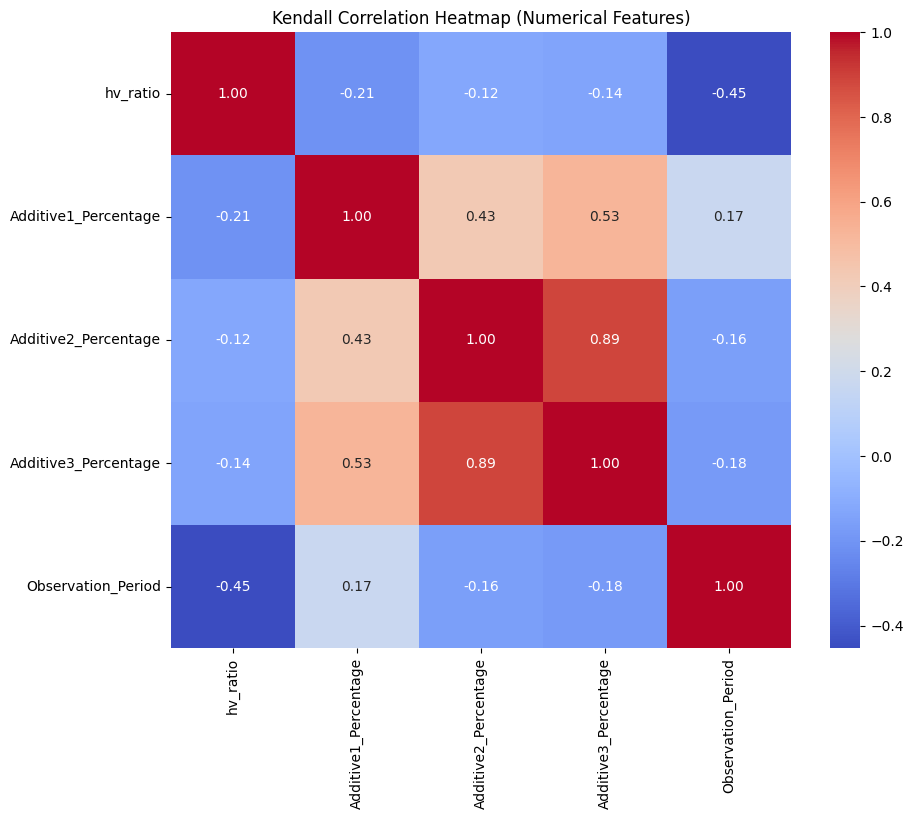

In [51]:
# Use Kendall correlation for numerical features between them
kendall_corr = X_train_clean[numerical_cols].corr(method='kendall')
plt.figure(figsize=(10, 8))
sns.heatmap(kendall_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Kendall Correlation Heatmap (Numerical Features)')
# plt.savefig('../plots/Kendall Correlation Heatmap - Ecotoxicity Model.png', dpi=600, bbox_inches='tight')

plt.show()

## Cramér's V (Cat vs Cat)

C:\Users\leoni\AppData\Local\Temp\ipykernel_26456\245906871.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train_clean.select_dtypes(include=['object', 'category']).columns.tolist()


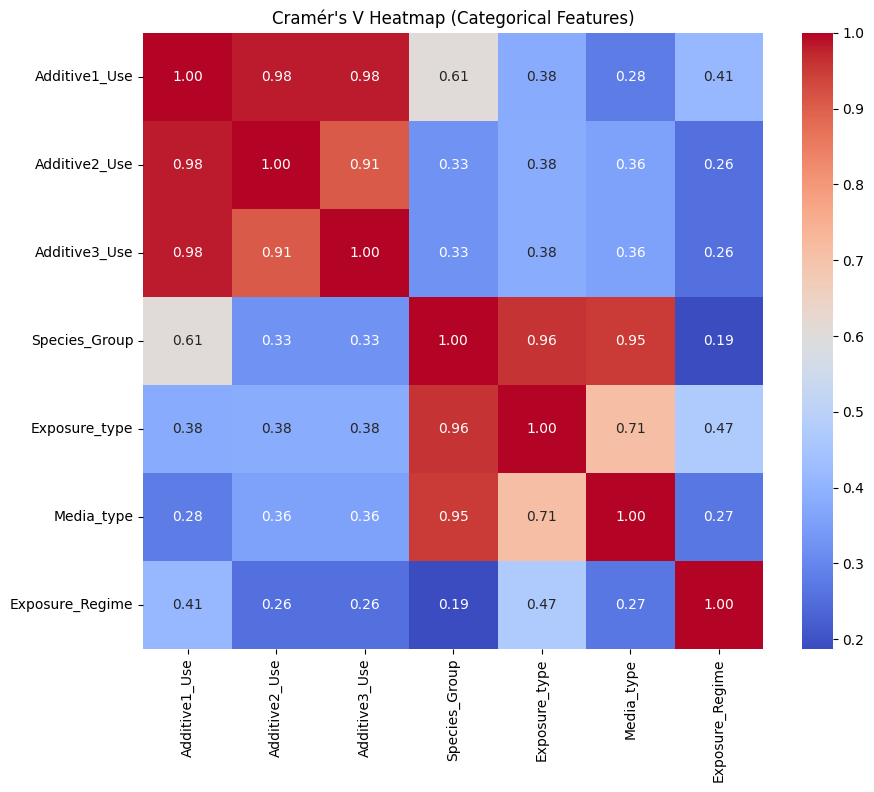

In [53]:
# Use cramer's V for categorical features between them
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))    
cat_cols = X_train_clean.select_dtypes(include=['object', 'category']).columns.tolist()
cramers_v_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols)
for col1 in cat_cols:
    for col2 in cat_cols:
        if col1 == col2:
            cramers_v_matrix.loc[col1, col2] = 1.0
        else:
            cramers_v_matrix.loc[col1, col2] = cramers_v(X_train_clean[col1], X_train_clean[col2])
plt.figure(figsize=(10, 8))
sns.heatmap(cramers_v_matrix.astype(float), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Cramér's V Heatmap (Categorical Features)")
plt.show()

## Drop Unnecessary Features

In [ ]:
# feature_to_drop = mi_scores_series.keys()[-1] # get the feature with the lowest MI score
# X_train_clean = X_train_clean.drop(columns=feature_to_drop)
# X_test_clean  = X_test_clean.drop(columns=feature_to_drop)
# print(f"Drop feature: {feature_to_drop}") 

# Machine Learning Algorithm

In [55]:
# Recompute numerical and categorical features 
numerical_cols = X_train_clean.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in X_train_clean.columns
                    if c not in numerical_cols and c != target]

print(f"Numerical features ({len(numerical_cols)}):")
for c in numerical_cols: print(f"  - {c}")
print(f"\nCategorical features ({len(categorical_cols)}):")
for c in categorical_cols: print(f"  - {c}")

features_num = numerical_cols
features_cat = categorical_cols 

Numerical features (5):
  - hv_ratio
  - Additive1_Percentage
  - Additive2_Percentage
  - Additive3_Percentage
  - Observation_Period

Categorical features (7):
  - Additive1_Use
  - Additive2_Use
  - Additive3_Use
  - Species_Group
  - Exposure_type
  - Media_type
  - Exposure_Regime


In [57]:
# Preprocessing pipeline
def build_preprocessor(features_num, features_cat):
    """
    Returns a fresh, unfitted ColumnTransformer.
    Call this every time you need a new preprocessor instance
    """
    return ColumnTransformer(
        transformers=[
            (
                "num",
                StandardScaler(),
                features_num
            ),
            (
                "cat",
                OneHotEncoder(
                    handle_unknown="ignore",   
                    sparse_output=False,
                    drop="if_binary"           
                ),
                features_cat
            ),
        ],
        remainder="drop",  # drop any column not explicitly listed
    )

## Applicability Domain

In [59]:
# Preprocessing only for Applicability domain
pre_ad = build_preprocessor(features_num, features_cat)
 
X_train_preprocessed = pre_ad.fit_transform(X_train_clean)
X_test_preprocessed  = pre_ad.transform(X_test_clean)
 
print("\nPreprocessed shapes:")
print(f"  X_train_preprocessed: {X_train_preprocessed.shape}")
print(f"  X_test_preprocessed:  {X_test_preprocessed.shape}")


Preprocessed shapes:
  X_train_preprocessed: (59, 20)
  X_test_preprocessed:  (14, 20)


In [61]:
# Applicability Domain check

doa_methods = {
    "Leverage":    Leverage(),
    "BoundingBox": BoundingBox()
}
 
in_doa_per_method = {}
for name, method in doa_methods.items():
    method.fit(X_train_preprocessed)
    preds = method.predict(X_test_preprocessed)
    in_doa_per_method[name] = np.array([bool(p["inDoa"]) for p in preds])
 
ad_df = pd.DataFrame(in_doa_per_method, index=X_test_clean.index)
ad_df["votes_in"]  = ad_df.sum(axis=1)
ad_df["votes_out"] = len(doa_methods) - ad_df["votes_in"]
ad_df["in_domain"] = ad_df["votes_in"] >= 2  # unanimous vote (must be in-domain in both methods)
 
print("\nPer-method in-domain counts (test set):")
for name in doa_methods:
    n_in  = int(ad_df[name].sum())
    n_out = int((~ad_df[name]).sum())
    print(f"  {name:<12}  in: {n_in:>3}   out: {n_out:>3}")
 
n_total  = len(ad_df)
n_in_maj = int(ad_df["in_domain"].sum())
print(f"\nUnanimous vote (>= 2/{len(doa_methods)} in-domain):")
print(f"  Kept (in-domain):     {n_in_maj} / {n_total}")
print(f"  Excluded (out-of-AD): {n_total - n_in_maj} / {n_total}")

# Preprocessed arrays no longer needed
del X_train_preprocessed, X_test_preprocessed, pre_ad



Per-method in-domain counts (test set):
  Leverage      in:  14   out:   0
  BoundingBox   in:  14   out:   0

Unanimous vote (>= 2/2 in-domain):
  Kept (in-domain):     14 / 14
  Excluded (out-of-AD): 0 / 14


In [63]:
# AD-filtered RAW test set - used for all evaluations below
in_domain_mask  = ad_df["in_domain"].values                              
X_test_clean_ad = X_test_clean.iloc[in_domain_mask].reset_index(drop=True)  
y_test_clean_ad = y_test_clean.iloc[in_domain_mask].reset_index(drop=True) 

In [65]:
y_train_clean.value_counts()

Toxicity_Classification
Non_Toxic    38
Toxic        21
Name: count, dtype: int64

# Jacpot Deployment

In [68]:
# Built Pycaret's datasets
train_data = X_train_clean.copy()
train_data[target] = y_train_clean.values

test_data_ad = X_test_clean_ad.copy()
test_data_ad[target] = y_test_clean_ad.values

train_data = train_data.drop(columns=cols_to_drop)
test_data_ad = test_data_ad.drop(columns=cols_to_drop)

print(train_data.columns.tolist())
print(test_data_ad.columns.tolist())

['hv_ratio', 'Additive1_Percentage', 'Additive2_Percentage', 'Additive3_Percentage', 'Observation_Period', 'Additive1_Use', 'Additive2_Use', 'Additive3_Use', 'Species_Group', 'Exposure_type', 'Media_type', 'Exposure_Regime', 'Toxicity_Classification']
['hv_ratio', 'Additive1_Percentage', 'Additive2_Percentage', 'Additive3_Percentage', 'Observation_Period', 'Additive1_Use', 'Additive2_Use', 'Additive3_Use', 'Species_Group', 'Exposure_type', 'Media_type', 'Exposure_Regime', 'Toxicity_Classification']


In [70]:
# Fix dtypes
for d in [train_data, test_data_ad]:
    string_cols = d.select_dtypes(include='string').columns
    category_cols = d.select_dtypes(include='category').columns
    d[string_cols] = d[string_cols].astype(object)
    d[category_cols] = d[category_cols].astype(object)

# Rebuild datasets
train_dataset = JaqpotTabularDataset(
    df=train_data,
    x_cols=train_data.drop(columns=[target]).columns.to_list(),
    y_cols=target,
    task="BINARY_CLASSIFICATION",
)
test_dataset = JaqpotTabularDataset(
    df=test_data_ad,
    x_cols=test_data_ad.drop(columns=[target]).columns.to_list(),
    y_cols=target,
    task="BINARY_CLASSIFICATION",
)

In [72]:
# Fix any remaining category dtype cols to object for jaqpotpy compatibility
cat_dtype_cols = train_data.select_dtypes("category").columns.tolist()
train_data[cat_dtype_cols] = train_data[cat_dtype_cols].astype(str)
test_data_ad[cat_dtype_cols] = test_data_ad[cat_dtype_cols].astype(str)

## Import model

In [75]:
string_cols = train_dataset.X.select_dtypes(include='string').columns
category_cols = train_dataset.X.select_dtypes(include='category').columns

print("string dtype columns:", string_cols.tolist())
print("category dtype columns:", category_cols.tolist())

train_dataset.X[string_cols] = train_dataset.X[string_cols].astype(object)
train_dataset.X[category_cols] = train_dataset.X[category_cols].astype(object)

print(train_dataset.X.dtypes.value_counts())

string dtype columns: []
category dtype columns: []
object     7
float64    5
Name: count, dtype: int64


In [77]:
features_num = [f for f in features_num if f not in cols_to_drop]
features_cat = [f for f in features_cat if f not in cols_to_drop]

In [102]:
import joblib
final_model = joblib.load('final_model_eco.pkl')

jaqpot_model = SklearnModel(
    dataset=train_dataset,
    model=final_model,
    doa=[Leverage(), BoundingBox()],
    preprocess_x=build_preprocessor(features_num, features_cat)
)
jaqpot_model.random_seed = 1231
jaqpot_model.fit()
print("Jaqpot model ready")

C:\Users\leoni\anaconda3\envs\pycaret_env\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.4.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\leoni\anaconda3\envs\pycaret_env\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.4.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Goodness-of-fit metrics on training set:
{'accuracy': 0.8135593220338984, 'balancedAccuracy': 0.8339598997493735, 'precision': array([0.76315789, 0.9047619 ]), 'recall': array([0.93548387, 0.67857143]), 'f1Score': array([0.84057971, 0.7755102 ]), 'jaccard': array([0.725     , 0.63333333]), 'matthewsCorrCoef': 0.6404214960081726, 'confusionMatrix': array([[29,  9],
       [ 2, 19]], dtype=int64)}
Jaqpot model ready


In [104]:
final_model.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': 'balanced_subsample',
 'criterion': 'gini',
 'max_depth': 4,
 'max_features': 0.7525926756492931,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 9.943127427569059e-09,
 'min_samples_leaf': 3,
 'min_samples_split': 4,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 38,
 'n_jobs': -1,
 'oob_score': False,
 'random_state': 1231,
 'verbose': 0,
 'warm_start': False}

In [106]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [108]:
# Perform cross-validation on the training data
cv_results = jaqpot_model.cross_validate(train_dataset, n_splits=NUM_SPLITS)
cv_results

{'accuracy': 0.6590909090909091,
 'balancedAccuracy': 0.678968253968254,
 'precision': array([0.68888889, 0.66904762]),
 'recall': array([0.77301587, 0.54904762]),
 'f1Score': array([0.70591631, 0.57131313]),
 'jaccard': array([0.55722222, 0.40357143]),
 'matthewsCorrCoef': 0.33903065442559277,
 'confusionMatrix': array([[5.2, 2.4],
        [1.6, 2.6]])}

In [110]:
# Evaluate the model on the test dataset
test_results = jaqpot_model.evaluate(test_dataset)
test_results

{'accuracy': 0.6428571428571429,
 'balancedAccuracy': 0.6777777777777778,
 'precision': array([0.55555556, 0.8       ]),
 'recall': array([0.83333333, 0.5       ]),
 'f1Score': array([0.66666667, 0.61538462]),
 'jaccard': array([0.5       , 0.44444444]),
 'matthewsCorrCoef': 0.34426518632954817,
 'confusionMatrix': array([[5, 4],
        [1, 4]], dtype=int64)}

In [112]:
# Conduct a randomization test to assess the model's robustness
jaqpot_model.randomization_test(
    train_dataset=train_dataset,
    test_dataset=test_dataset,
    n_iters=10,
)

{'iteration_0': {'Train': {'accuracy': 0.6610169491525424,
   'balancedAccuracy': 0.6622807017543859,
   'precision': array([0.65789474, 0.66666667]),
   'recall': array([0.78125   , 0.51851852]),
   'f1Score': array([0.71428571, 0.58333333]),
   'jaccard': array([0.55555556, 0.41176471]),
   'matthewsCorrCoef': 0.3119187251482598,
   'confusionMatrix': array([[25, 13],
          [ 7, 14]], dtype=int64)},
  'Test': {'accuracy': 0.6428571428571429,
   'balancedAccuracy': 0.5888888888888889,
   'precision': array([0.77777778, 0.4       ]),
   'recall': array([0.7, 0.5]),
   'f1Score': array([0.73684211, 0.44444444]),
   'jaccard': array([0.58333333, 0.28571429]),
   'matthewsCorrCoef': 0.18856180831641267,
   'confusionMatrix': array([[7, 2],
          [3, 2]], dtype=int64)}},
 'iteration_1': {'Train': {'accuracy': 0.7288135593220338,
   'balancedAccuracy': 0.7149122807017544,
   'precision': array([0.76315789, 0.66666667]),
   'recall': array([0.80555556, 0.60869565]),
   'f1Score': arr

## Applicability domain

In [115]:
doa_predictions = jaqpot_model.predict_doa(test_dataset)

summary = {}
for key in ['LEVERAGE','BOUNDING_BOX']:
    df_doa = pd.DataFrame(doa_predictions[key])
    summary[key] = {
        'n_total': len(df_doa),
        'n_in': int(df_doa['inDoa'].sum()),
        'n_out': int((~df_doa['inDoa']).sum())
    }
summary

{'LEVERAGE': {'n_total': 14, 'n_in': 14, 'n_out': 0},
 'BOUNDING_BOX': {'n_total': 14, 'n_in': 14, 'n_out': 0}}

## Confusion matrix

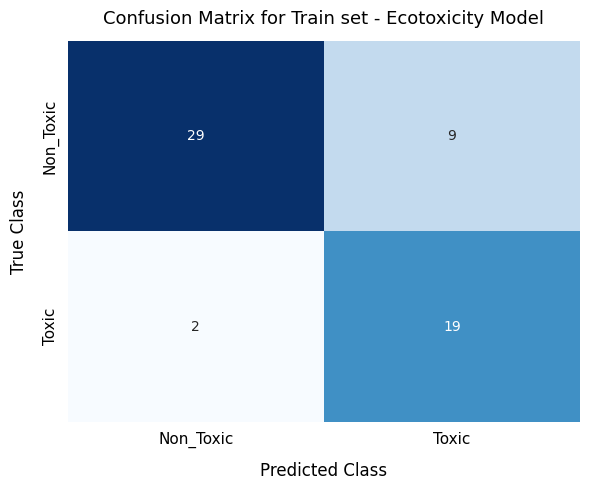

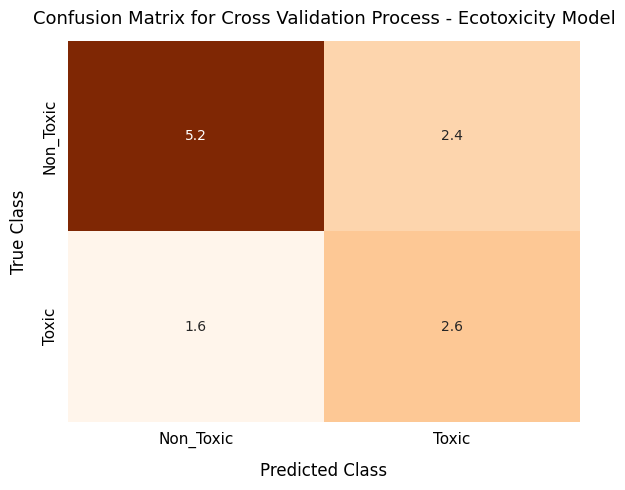

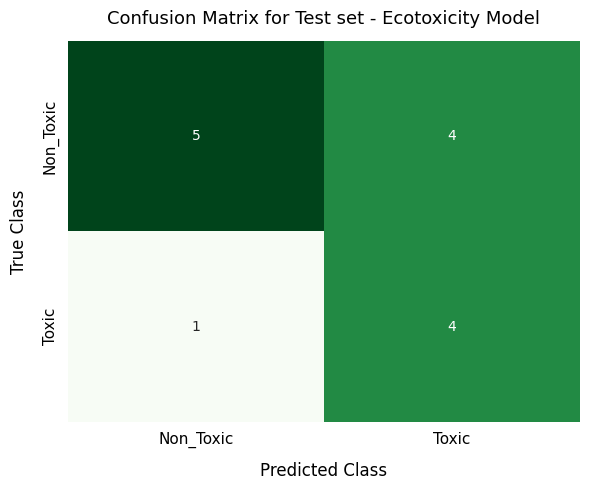

In [118]:
# Plot confusion matrix for train and test set based on the tuned model predictions
def plot_confusion_matrix(cm, title, color, fmt='d'):
    plt.figure(figsize=(6, 5))
    ax = sns.heatmap(cm, annot=True, fmt=fmt, cmap=color, cbar=False)
    
    classes = sorted(y_train_clean.unique())
    ax.set_xticklabels(classes, fontsize=11)
    ax.set_yticklabels(classes, fontsize=11)    
    # Remove tick marks and spines
    ax.tick_params(which='both', bottom=False, left=False)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xlabel('Predicted Class', fontsize=12, labelpad=10)
    ax.set_ylabel('True Class', fontsize=12, labelpad=10)
    ax.set_title(title, fontsize=13, pad=12)
    plt.tight_layout()
    plt.savefig(f'{title.replace(" ", "_").lower()}.png', dpi=600, bbox_inches='tight')
    plt.show() 
    
# Confusion matrix for train set
train_results = jaqpot_model.train_scores
cm_train = train_results['confusionMatrix']
plot_confusion_matrix(cm_train, 'Confusion Matrix for Train set - Ecotoxicity Model', 'Blues')

# Confusion matrix for cv in train set
cm_cv = cv_results['confusionMatrix']
plot_confusion_matrix(cm_cv, 'Confusion Matrix for Cross Validation Process - Ecotoxicity Model', 'Oranges', fmt='.1f')

# Confusion matrix for test set
cm_test = test_results['confusionMatrix']
plot_confusion_matrix(cm_test, 'Confusion Matrix for Test set - Ecotoxicity Model', 'Greens')

## Upload model on Jaqpot

In [121]:
# Deploy
jaqpot = Jaqpot()
jaqpot.login()
jaqpot_model.deploy_on_jaqpot(
    jaqpot=jaqpot,
    name="Ecotoxicity classification model for PHBV polymers A.N.I.P.H.",
    description="Predict ecotoxicity of PHBV polymers.",
    visibility="PUBLIC",
)

Open this URL in your browser and log in:
https://login.jaqpot.org/realms/jaqpot/protocol/openid-connect/auth?client_id=jaqpot-client&response_type=code&redirect_uri=urn:ietf:wg:oauth:2.0:oob&scope=openid email profile&state=random_state_value&nonce=


Enter the authorization code you received:  ········


  2026-07-25 22:42:34,845 - INFO - Model has been successfully uploaded. The url of the model is https://app.jaqpot.org/dashboard/models/2405


In [123]:
train_dataset.X[features_num].agg(['min', 'max'])

,hv_ratio,Additive1_Percentage,Additive2_Percentage,Additive3_Percentage,Observation_Period
min,0.0,0.0,0.0,0.0,0.020833
max,12.0,72.0,10.0,2.0,183.000000
